In [5]:
import pandas as pd
import json

def load_data(idx: str, file_template: str = "data/streamlit/deepseek_llama_8b/gpqa/{idx}.csv") -> pd.DataFrame:
    """Load CSV data for a given index."""
    df = pd.read_csv(file_template.format(idx=idx))
    return df


base_data = json.load(open("data/streamlit/deepseek_llama_8b/gpqa/base_data.json"))

In [6]:
from typing import Tuple, Optional

def get_final_convergence(df: pd.DataFrame) -> Optional[Tuple[int, str]]:
    """
    Find the timestep when an outcome reaches probability 1.0 and stays there until the end.
    
    Returns:
        (timestep, outcome) if found, None otherwise
    """
    max_t = df['t'].max()
    
    # Check if there's an outcome with probability 1.0 at the final timestep
    final_rows = df[df['t'] == max_t]
    final_locked = final_rows[final_rows['outcome_probability'] == 1.0]
    
    if final_locked.empty:
        return None  # No convergence at the end
    
    # Get the outcome that's locked at the end
    final_outcome = final_locked['outcome'].iloc[0]
    
    # Now find the earliest timestep where this outcome became 1.0 and stayed 1.0
    # Filter for this outcome only
    outcome_df = df[df['outcome'] == final_outcome].sort_values('t')
    
    # Find the earliest timestep from which probability stays 1.0
    # Work backwards from the end to find where it first became 1.0
    timesteps = outcome_df['t'].values
    probs = outcome_df['outcome_probability'].values
    
    # Find the last index where probability is not 1.0
    convergence_start_idx = 0
    for i in range(len(probs) - 1, -1, -1):
        if probs[i] != 1.0:
            convergence_start_idx = i + 1
            break
    
    if convergence_start_idx >= len(timesteps):
        return None  # Edge case: never converged
    
    convergence_t = timesteps[convergence_start_idx]
    
    return int(convergence_t), final_outcome


def get_convergence_for_index(idx: str, file_template: str = "data/streamlit/deepseek_llama_8b/gpqa/{idx}.csv") -> Optional[Tuple[int, str]]:
    """
    Load data for index and return the final convergence timestep and outcome.
    """
    df = load_data(idx, file_template)
    return get_final_convergence(df)


In [11]:
from transformers import AutoTokenizer

def find_token_index(tokenizer, token_to_find, token_ids):
    for i,tok in enumerate(tokenizer.convert_ids_to_tokens(token_ids)):
        if token_to_find in tok:
            return i
    return -1


tokenizer = AutoTokenizer.from_pretrained("deepseek-ai/DeepSeek-R1-Distill-Llama-8B")
idxs = [str(i).zfill(2) for i in range(0, 28)]
stats = {}

for i in idxs:
    entry = {}
    df = load_data(i)
    converged_timestep, converged_outcome = get_convergence_for_index(i)
    entry["converged_outcome"] = converged_outcome
    entry["converged_timestep"] = converged_timestep
    entry["base_outcome"] = base_data[int(i)]["clean_answer"]
    entry["correct_outcome"] = base_data[int(i)]["correct_letter"]
    entry["output_length"] = len(base_data[int(i)]["output_token_ids"])
    entry["think_finish_idx"] = find_token_index(tokenizer, "</think>", base_data[int(i)]["output_token_ids"])
    entry["is_correct"] = entry["converged_outcome"] == entry["correct_outcome"]
    lowest_timestep = df['t'].min()
    correct_letter = base_data[int(i)]["correct_letter"]
    lowest_timestep_correct_row = df[(df['t'] == lowest_timestep) & (df['outcome'] == correct_letter)]
    lowest_timestamp_convergence_row = df[(df['t'] == lowest_timestep) & (df['outcome'] == entry["converged_outcome"])]
    outcome_probability = lowest_timestep_correct_row['outcome_probability'].values
    outcome_probability = outcome_probability[0] if len(outcome_probability) > 0 else 0
    entry["outcome_probability_at_lowest_timestep"] = outcome_probability
    entry["convergence_probability_at_lowest_timestep"] = lowest_timestamp_convergence_row['outcome_probability'].values[0] if len(lowest_timestamp_convergence_row['outcome_probability'].values) > 0 else 0
    entry["lowest_timestep"] = lowest_timestep
    entry["dist_from_think_end"] = entry["think_finish_idx"] - entry["converged_timestep"]
    stats[i] = entry
    del df

stats = pd.DataFrame(stats)
stats = stats.T
stats

,converged_outcome,converged_timestep,base_outcome,correct_outcome,output_length,think_finish_idx,is_correct,outcome_probability_at_lowest_timestep,convergence_probability_at_lowest_timestep,lowest_timestep,dist_from_think_end
00,A,4861,A,B,5404,4861,False,0.85,0.15,36,0
01,C,7255,C,D,7267,6846,False,0.2,0.05,24,-409
02,C,5789,C,D,6612,5879,False,0.5,0.1,30,90
03,A,3289,A,B,3815,3337,False,0.25,0.35,28,48
04,D,4905,D,B,5165,4760,False,0.65,0.3,20,-145
05,A,7596,A,D,8288,7670,False,0.45,0.4,33,74
06,A,4150,A,A,4580,4176,True,0.4,0.4,31,26
07,D,6663,D,A,7624,6902,False,0.05,0.4,19,239
08,B,924,B,D,1525,1133,False,0,0.9,16,209
09,A,411,A,A,773,505,True,0.75,0.75,15,94


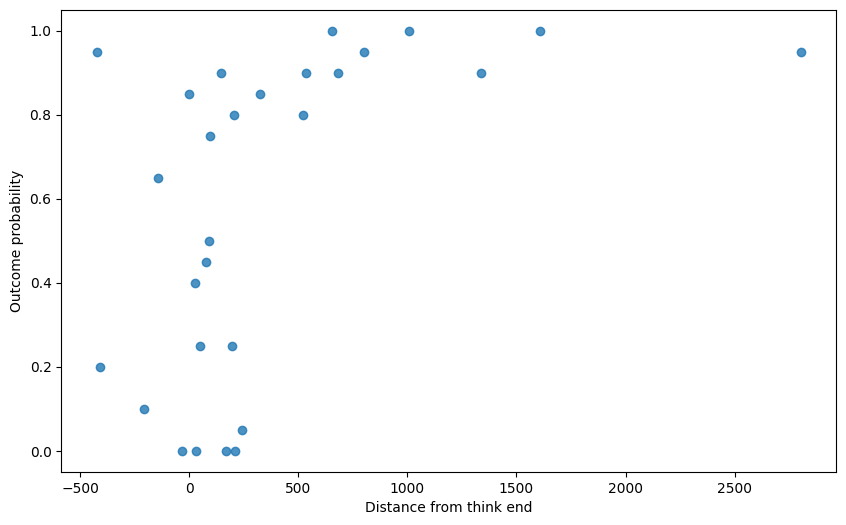

In [15]:
import matplotlib.pyplot as plt

# Create a figure and axis
plt.subplots(figsize=(10, 6))
ys = stats["outcome_probability_at_lowest_timestep"].values
xs = stats["dist_from_think_end"].values
plt.scatter(xs, ys, alpha=0.8)
plt.ylabel("Outcome probability")
plt.xlabel("Distance from think end")
plt.show()

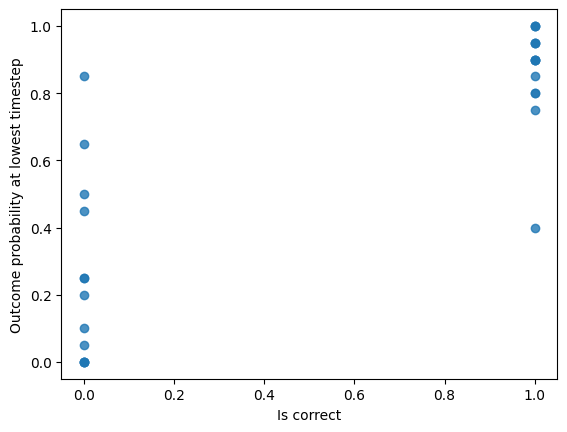

In [21]:
xs = stats["is_correct"].values
ys = stats["outcome_probability_at_lowest_timestep"].values
plt.scatter(xs, ys, alpha=0.8)
plt.ylabel("Outcome probability at lowest timestep")
plt.xlabel("Is correct")
plt.show()
